## Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif , RFE, SequentialFeatureSelector, VarianceThreshold
from sklearn.preprocessing import Normalizer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import time


## Data Loading & Splitting

In [85]:
dataset = pd.read_csv("feature_vectors_syscallsbinders_frequency_5_Cat.csv")

before= len(dataset)
dataset = dataset.drop_duplicates()

y= dataset['Class']
X= dataset.drop(columns=['Class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    shuffle=True,
    random_state=42
)


print(f"Rows dropped: {before - len(dataset)}")

Rows dropped: 72


In [86]:
label_encoder = LabelEncoder()
y_train = pd.Series(label_encoder.fit_transform(y_train), index=y_train.index, name=y_train.name)
y_test = pd.Series(label_encoder.transform(y_test), index=y_test.index, name=y_test.name)

print("Unique encoded y_train classes:", y_train.value_counts().sort_index())

label_map = {
    0: "Adware",
    1: "Banking",
    2: "SMS",
    3: "Riskware",
    4: "Benign"
}

counts =pd.DataFrame({
    'Train': y_train.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index()
})
counts.index = counts.index.map(label_map)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nLabel distribution:")
print(counts)

Unique encoded y_train classes: Class
0     877
1    1431
2    2732
3    1774
4    1254
Name: count, dtype: int64
Train shape: (8068, 470)
Test shape: (3458, 470)

Label distribution:
          Train  Test
Class                
Adware      877   376
Banking    1431   613
SMS        2732  1171
Riskware   1774   760
Benign     1254   538


## Data Cleaninig

In [34]:
assert X_train.isnull().sum().sum() == 0, "Unexpected missing values found"
assert X_test.isnull().sum().sum() == 0, "Unexpected missing values found"

assert np.isinf(X_train.values).sum() == 0, "Inf values found in X_train"
assert np.isinf(X_test.values).sum() == 0, "Inf values found in X_test"
print("No missing values")

zero_var_cols = X_train.columns[X_train.nunique() == 1]
X_train = X_train.drop(columns=zero_var_cols)
X_test = X_test.drop(columns=zero_var_cols)
print(f"Dropped {len(zero_var_cols)} zero-variance columns")

print("\nData types (train):")
print(X_train.dtypes.value_counts())
print("\nData types (test):")
print(X_test.dtypes.value_counts())

No missing values
Dropped 21 zero-variance columns

Data types (train):
int64    449
Name: count, dtype: int64

Data types (test):
int64    449
Name: count, dtype: int64


## Preprocessing

### Feature Selection: Filter Methods

In [36]:
# chi2
tic = time.time()
chi2_selector = SelectKBest(chi2, k=250)
chi2_selector.fit(X_train, y_train)
toc = time.time()
chi2_features = X_train.columns[chi2_selector.get_support()]
X_train_chi2 = X_train[chi2_features]
X_test_chi2 = X_test[chi2_features]  

print(f"Runtime: {toc-tic}")

Runtime: 0.10168290138244629


In [50]:
tic = time.time()
var_selector = VarianceThreshold(threshold=0.1)
var_selector.fit(X_train, y_train)
toc = time.time()

var_features = X_train.columns[var_selector.get_support()]
X_train_var = X_train[var_features]
X_test_var = X_test[var_features]

print(f"Variance selected {len(var_features)} features")
print(f"Overlap with chi2: {len(set(chi2_features) & set(var_features))}")
print(f"Overlap with MI: {len(set(MI_features) & set(var_features))}")
print(f"Runtime: {toc-tic}")

Variance selected 256 features
Overlap with chi2: 242
Overlap with MI: 150
Runtime: 0.10804915428161621


In [116]:
# Mutual Information
tic = time.time()
MI_selector = SelectKBest(mutual_info_classif, k=40)
MI_selector.fit(X_train_var, y_train)
toc = time.time()

MI_features = X_train_var.columns[MI_selector.get_support()]
X_train_MI = X_train[MI_features]
X_test_MI = X_test[MI_features]

print(f"Runtime: {toc-tic}")

Runtime: 15.957197189331055


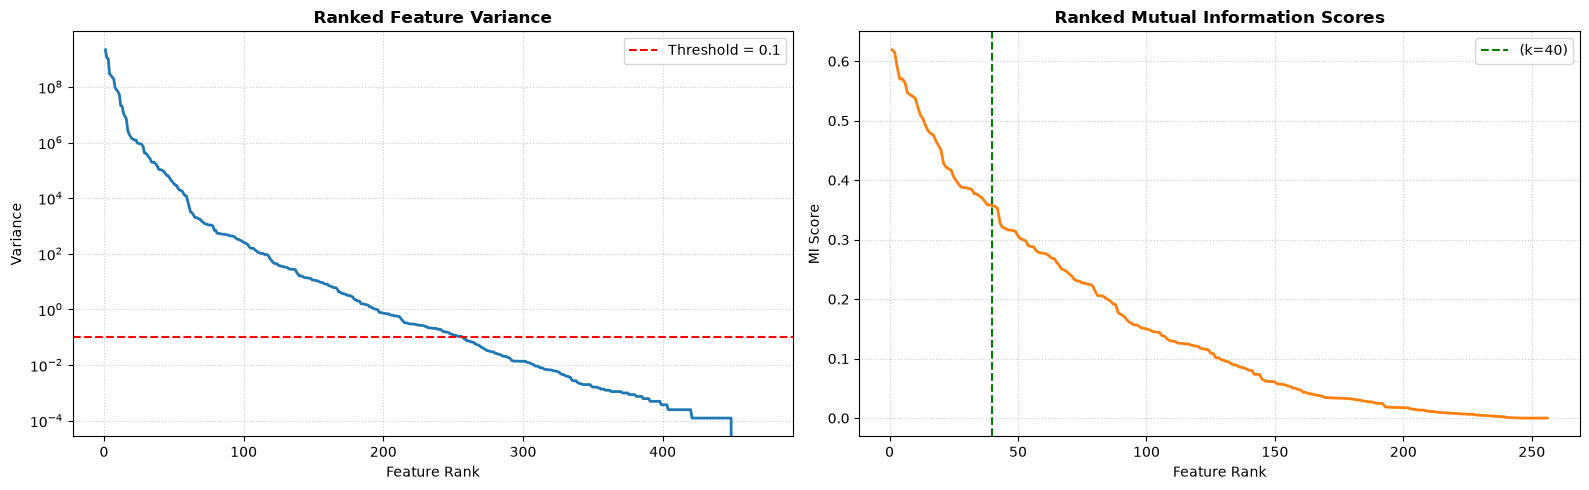

In [125]:
mi_scores = pd.Series(MI_selector.scores_, index=X_train_var.columns).sort_values(ascending=False)

variances = X_train.var().sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Variance Plot
axes[0].plot(range(1, len(variances) + 1), variances.values, color="tab:blue", lw=2)
axes[0].axhline(y=0.1, color="red", linestyle="--", label="Threshold = 0.1")

axes[0].set_title("Ranked Feature Variance", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Feature Rank")
axes[0].set_ylabel("Variance")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", linestyle=":", alpha=0.6)
axes[0].legend()

# MI Scores Plot
axes[1].plot(range(1, len(mi_scores) + 1), mi_scores.values, color="tab:orange", lw=2)
axes[1].axvline(x=40, color="green", linestyle="--", label="(k=40)")

axes[1].set_title("Ranked Mutual Information Scores", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Feature Rank")
axes[1].set_ylabel("MI Score")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [118]:
top_40 = [
    "getInstallerPackageName",
    "_newselect",
    "mprotect",
    "getPackageInfo",
    "CREATE_FOLDER_____",
    "getReceiverInfo",
    "mkdir",
    "pwrite64",
    "getServiceInfo",
    "pread64",
    "unlink",
    "munmap",
    "statfs64",
    "getActivityInfo",
    "fdatasync",
    "FS_PIPE_ACCESS___",
    "FS_ACCESS(READ)____",
    "FS_PIPE_ACCESS(WRITE)___",
    "FS_ACCESS____",
    "mmap2",
    "FS_ACCESS()____",
    "pipe",
    "fcntl64",
    "FS_ACCESS(CREATE__WRITE)__",
    "nanosleep",
    "getApplicationInfo",
    "FS_ACCESS(CREATE__READ__WRITE)",
    "rename",
    "access",
    "chmod",
    "gettid",
    "FS_ACCESS(CREATE)____",
    "brk",
    "DEVICE_ACCESS_____",
    "queryIntentServices",
    "NETWORK_ACCESS____",
    "stat64",
    "FS_ACCESS(WRITE)____",
    "open",
    "lstat64",
]


found_features = set(top_40).intersection(set(MI_features))
missing_features = set(top_40) - found_features

print(f"Overlap: {len(found_features)} / {len(top_40)} features.")

print(f"\nMissing Features ({len(missing_features)}):")

X_train_40 = X_train[top_40]
X_test_40 = X_test[top_40]

print("Train shape:", X_train_40.shape)
print("Test shape:", X_test_40.shape)

Overlap: 17 / 40 features.

Missing Features (23):
Train shape: (8068, 40)
Test shape: (3458, 40)


In [110]:
def scaler(X_train, X_test):
    normalizer = Normalizer(norm="l2")
    X_train_scaled = pd.DataFrame(normalizer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(normalizer.transform(X_test), columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_test_scaled


X_train_scaled, X_test_scaled = scaler(X_train, X_test)
X_train_40, X_test_40 = scaler(X_train_40, X_test_40)
X_train_MI, X_test_MI = scaler(X_train_MI, X_test_MI)

### Feature Selection: Wrapper Methods

In [122]:
xgb = XGBClassifier(n_estimators=50, max_depth=3, n_jobs=-1, random_state=42)

rfe_selector = RFE(estimator=xgb, n_features_to_select=25, step=5, verbose=1)

X_train_rfe = pd.DataFrame(
    rfe_selector.fit_transform(X_train_40, y_train),
    columns=X_train_40.columns[rfe_selector.get_support()],
    index=X_train_40.index
)
X_test_rfe = pd.DataFrame(
    rfe_selector.transform(X_test_40),
    columns=X_train_40.columns[rfe_selector.get_support()],
    index=X_test_40.index
)

print(f"Final feature count: {X_train_rfe.shape[1]}")

Fitting estimator with 40 features.
Fitting estimator with 35 features.
Fitting estimator with 30 features.
Final feature count: 25


In [130]:
tic = time.time()
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

backward_sel = SequentialFeatureSelector(
    estimator=xgb,
    n_features_to_select=20,
    direction='backward',
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
)

X_train_bs = pd.DataFrame(
    backward_sel.fit_transform(X_train_rfe, y_train),
    columns=X_train_rfe.columns[backward_sel.get_support()],
    index=X_train_rfe.index)

toc = time.time()
print(f"Runtime: {toc-tic}")

X_test_bs = pd.DataFrame(
    backward_sel.transform(X_test_rfe),
    columns=X_train_rfe.columns[backward_sel.get_support()],
    index=X_test_rfe.index)

print(f"Final feature count: {X_train_bs.shape[1]}")

Runtime: 235.2312879562378
Final feature count: 20


In [132]:
train_final = pd.concat([X_train_bs, y_train], axis = 1)
test_final = pd.concat([X_test_bs, y_test], axis = 1)

train_final.to_csv(path_or_buf = './train_final.csv', index = False)
test_final.to_csv(path_or_buf = './test_final.csv', index = False)


print(train_final.shape)
print(test_final.shape)

(8068, 21)
(3458, 21)


In [133]:
train_final = pd.concat([X_train_MI, y_train], axis = 1)
test_final = pd.concat([X_test_MI, y_test], axis = 1)

train_final.to_csv(path_or_buf = './train_MI.csv', index = False)
test_final.to_csv(path_or_buf = './test_MI.csv', index = False)


print(train_final.shape)
print(test_final.shape)

(8068, 41)
(3458, 41)


In [133]:
train_final = pd.concat([X_train_40, y_train], axis = 1)
test_final = pd.concat([X_test_40, y_test], axis = 1)

train_final.to_csv(path_or_buf = './train_40.csv', index = False)
test_final.to_csv(path_or_buf = './test_40.csv', index = False)


print(train_final.shape)
print(test_final.shape)

(8068, 41)
(3458, 41)
